# 01 — Detections QA (vClaire v2): ESP_069669_2220

Stage 0–1 walking skeleton on the **vClaire 40-image v2 dataset** (`config_v2.yaml`).
Loads the manifest + config, resolves the target CTX CRS, reprojects the
ESP_069669_2220 BoulderNet detections, plots the polygon footprint with the manifest
center + centroid residual, and (last section) overlays the polygons on the **full-res
HiRISE** to confirm they sit on individual boulders.

Imports from `src/`; computation happens in the modules — this notebook is for inspection.

**Why ESP_069669_2220?** It is in both the original priority10 (v1) and the vClaire (v2)
sets, so it's a clean continuity anchor: under v2 it now carries the denser vClaire
detections (~35k polygons vs ~1.5k in v1). Its `.prj` is trusted (no SP1 correction
needed), so the source and native-window CRSs match — ideal for the localization overlay.
Set `CONFIG_NAME = "config.yaml"` in the setup cell to inspect the v1 version.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from pyproj import CRS, Transformer

from src import detections, manifest as M, qa
from src.config import load_config, REPO_ROOT
from src.ctx_retrieve import resolve_target_crs

# Dataset selector: defaults to the vClaire 40-image v2 dataset; set "config.yaml" for v1.
CONFIG_NAME = "config_v2.yaml"
OBS_ID = "ESP_069669_2220"   # in both v1 and v2; under v2 it shows the denser vClaire detections
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(CONFIG_NAME)
df = M.load_manifest(cfg.manifest_path)
row = df.set_index("ObsId").loc[OBS_ID]
print(f"config: {CONFIG_NAME}   detections_root: {cfg.detections_root.name}")
print(f"manifest center: lat={row['CenterLat']:.4f}, lon_180={row['CenterLon_180']:.4f}, tile={row['CTX_TileName']}")

config: config_v2.yaml   detections_root: hirise_40_vClaire
manifest center: lat=41.8156, lon_180=0.7470, tile=E000_N40


In [2]:
target_wkt = resolve_target_crs(cfg)
target_crs = CRS.from_user_input(target_wkt)
print(f"target CRS name: {target_crs.name}")
print(f"sphere radius:   {target_crs.ellipsoid.semi_major_metre:.3f} m")
print(f"central meridian: {target_crs.coordinate_operation.params[1].value:.1f}° (Longitude of natural origin)")
print(f"config hash:      {cfg.hash[:12]}")

target CRS name: Mars_2000_Equidistant_Cylindrical
sphere radius:   3396190.000 m
central meridian: 0.0° (Longitude of natural origin)
config hash:      8d208c60a1d1


In [3]:
gdf_t, gpkg, correction = detections.stage1_one_image(
    OBS_ID,
    detections_root=cfg.detections_root,
    target_crs=target_wkt,
    cache_dir=cfg.cache_dir,
    config_hash=cfg.hash,
    manifest_row=row,
)
print(f"reprojected polygons: {len(gdf_t)}  (cache: {gpkg})")
print(f"correction: {correction}")
result = qa.assert_centroid_consistent(
    gdf_t,
    obs_id=OBS_ID,
    manifest_lat_deg=float(row['CenterLat']),
    manifest_lon_deg=float(row['CenterLon_180']),
    max_km=float(cfg['sanity']['centroid_max_km']),
)
print(f"centroid residual: {result.distance_m:.1f} m  (threshold {result.threshold_m:.0f} m)")

reprojected polygons: 35238  (cache: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\cache_v2\reprojected_detections\ESP_069669_2220.gpkg)
correction: {'status': 'trusted_prj'}


centroid residual: 1555.0 m  (threshold 15000 m)


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\01_detections_ESP_069669_2220.png


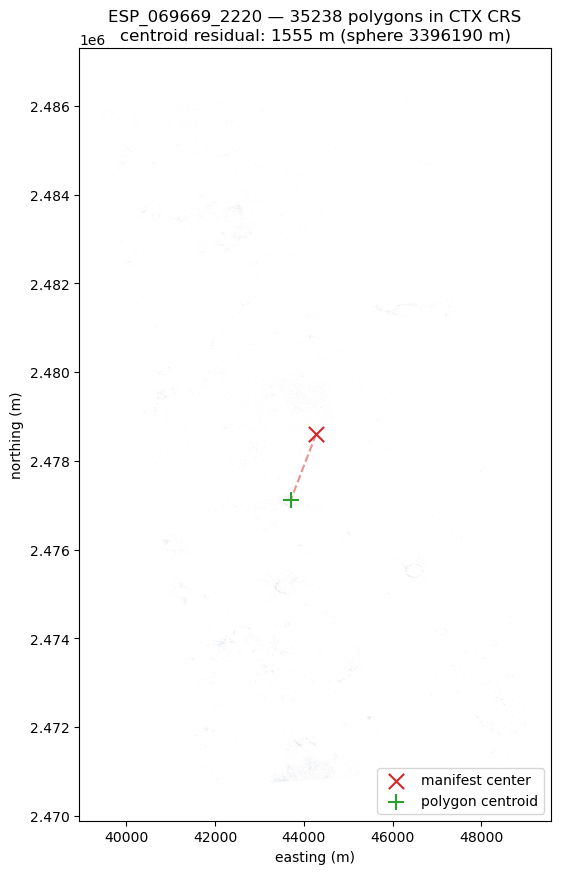

In [4]:
to_target = Transformer.from_crs(target_crs.geodetic_crs, target_crs, always_xy=True)
manifest_x, manifest_y = to_target.transform(row['CenterLon_180'], row['CenterLat'])
union = gdf_t.geometry.union_all()
cx, cy = union.centroid.x, union.centroid.y

fig, ax = plt.subplots(figsize=(7, 9))
gdf_t.plot(ax=ax, color='#1f77b4', edgecolor='none', alpha=0.7)
ax.scatter([manifest_x], [manifest_y], marker='x', s=120, color='#d62728', label='manifest center', zorder=5)
ax.scatter([cx], [cy], marker='+', s=140, color='#2ca02c', label='polygon centroid', zorder=5)
ax.plot([manifest_x, cx], [manifest_y, cy], color='#d62728', linestyle='--', alpha=0.5)
ax.set_xlabel('easting (m)')
ax.set_ylabel('northing (m)')
ax.set_title(f"{OBS_ID} — {len(gdf_t)} polygons in CTX CRS\n"
             f"centroid residual: {result.distance_m:.0f} m (sphere {result.target_sphere_m:.0f} m)")
ax.set_aspect('equal')
ax.legend(loc='lower right')
fig.tight_layout()
out_path = FIG_DIR / f"01_detections_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")

## Boulder localization on full-res HiRISE

The footprint plot above confirms gross placement (centroid near the manifest centre).
This is the **fine** check: at native HiRISE resolution (~0.25–0.5 m/px), zoomed to ~120 m
on the densest boulder cluster, the red BoulderNet polygons should sit **exactly on
individual boulders** (each bright cap + dark shadow). Dense where the boulder field is
dense, absent on smooth ground. This validates that the detection geometry is correctly
located in the image it was detected on — the foundation the Stage 1 reproject + Stage 3
co-registration then carry onto the CTX grid (see notebook 05 for the CTX-side checks).

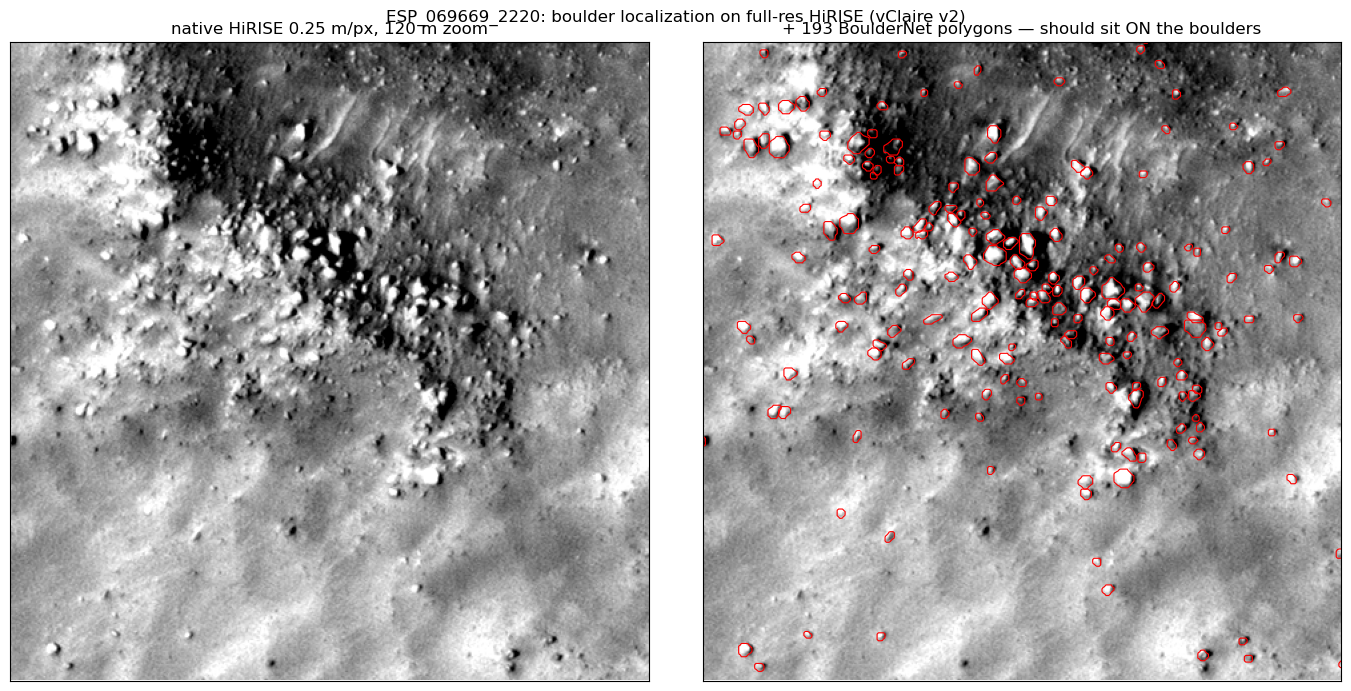

In [5]:
# Full-resolution localization: do the polygons sit on individual boulders?
# Overlay the BoulderNet polygons on a tight native-HiRISE zoom (~120 m). ESP_069669_2220
# is trusted-prj, so the source shapefile CRS == the native-window CRS (no reprojection in
# play) -- the cleanest possible test that detections land on the actual boulders.
import geopandas as gpd
import numpy as np
from src.detections import drop_null_geometries
from src.hirise_imagery import ensure_jp2_local, read_native_window

WIN_M = 120.0
shp = M.find_shapefile(OBS_ID, cfg.detections_root)
gsrc, _ = drop_null_geometries(gpd.read_file(shp))   # source HiRISE CRS
ensure_jp2_local(OBS_ID, str(row["JP2_URL"]), cfg.cache_dir)

# Densest ~WIN_M cell from polygon centroids (source-CRS metres).
cen = gsrc.geometry.centroid
cx, cy = cen.x.to_numpy(), cen.y.to_numpy()
xed = np.arange(cx.min(), cx.max() + WIN_M, WIN_M)
yed = np.arange(cy.min(), cy.max() + WIN_M, WIN_M)
Hh, _, _ = np.histogram2d(cx, cy, bins=[xed, yed])
ix, iy = np.unravel_index(np.argmax(Hh), Hh.shape)
bounds = (xed[ix], yed[iy], xed[ix] + WIN_M, yed[iy] + WIN_M)

arr, T, _ = read_native_window(OBS_ID, str(row["JP2_URL"]), bounds, cfg.cache_dir, "loc_check")
a, c, e, f = T.a, T.c, T.e, T.f
gpx = gsrc.geometry.affine_transform([1 / a, 0, 0, 1 / e, -c / a, -f / e])  # world -> window px

def _stretch(x):
    x = x.astype(float); m = x > 0
    lo, hi = np.percentile(x[m], (2, 98)) if m.any() else (0, 1)
    return np.clip((x - lo) / max(hi - lo, 1e-9), 0, 1)

H, W = arr.shape
inwin = gpx.cx[0:W, 0:H]
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(_stretch(arr), cmap="gray"); ax[0].set_title(f"native HiRISE {abs(a):.2f} m/px, {WIN_M:.0f} m zoom")
ax[1].imshow(_stretch(arr), cmap="gray")
inwin.plot(ax=ax[1], facecolor="none", edgecolor="red", linewidth=0.8)
ax[1].set_title(f"+ {inwin.shape[0]} BoulderNet polygons — should sit ON the boulders")
for a_ in ax:
    a_.set_xlim(0, W); a_.set_ylim(H, 0); a_.set_xticks([]); a_.set_yticks([])
fig.suptitle(f"{OBS_ID}: boulder localization on full-res HiRISE (vClaire v2)")
fig.tight_layout()
fig.savefig(FIG_DIR / f"01_localization_fullres_{OBS_ID}.png", dpi=140)
plt.show()